# Clase 1: Introducción al Machine Learning

En este laboratorio vamos a:

1. Ver un ejemplo pequeño de aprendizaje supervisado.
2. Comparar "programar reglas a mano" vs. "dejar que un modelo aprenda".
3. Explorar un dataset real con pandas.
4. Hacer un primer ejercicio de clasificación no supervisada (clustering) muy simple.

El objetivo de este laboratorio no es entender los algoritmos, sino **ver a Machine Learning funcionando**.

## 1. Programar reglas a mano vs. aprender de datos

Supongamos que queremos decidir si un mail es spam o no, mirando cuántas veces aparece la palabra "gratis".

In [ ]:
def es_spam_regla(cantidad_veces_gratis):
    return cantidad_veces_gratis >= 3

for veces in [0, 1, 3, 5]:
    print(veces, "->", es_spam_regla(veces))

0 -> False
1 -> False
3 -> True
5 -> True


El problema: **nosotros elegimos el número 3** a ojo. ¿Y si la regla real depende de varias palabras a la vez, o de patrones que no se nos ocurren?

En Machine Learning, en cambio, le damos ejemplos ya etiquetados (mails marcados como spam o no) y dejamos que el algoritmo encuentre el patrón.

In [8]:
import numpy as np

# Puede ser: [cantidad de veces que aparece la palabra "gratis", cantidad de links del mail]
X = np.array([
    [0, 0],
    [1, 0],
    [0, 1],
    [4, 3],
    [5, 5],
    [3, 4],
    [0, 0],
    [6, 2],
])
y = np.array([0, 0, 0, 1, 1, 1, 0, 1])  # 0 = no es spam, 1 = es spam

print("Features (X):\n", X)
print("Etiquetas (y):", y)

Features (X):
 [[0 0]
 [1 0]
 [0 1]
 [4 3]
 [5 5]
 [3 4]
 [0 0]
 [6 2]]
Etiquetas (y): [0 0 0 1 1 1 0 1]


In [19]:
# Necesitamos scikit-learn. 
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression()
modelo.fit(X, y)

# Probamos con un mail nuevo: aparece "gratis" 2 veces y tiene 2 links
nuevo_mail = [[2, 2]]
prediccion = modelo.predict(nuevo_mail)
print("¿Es spam?", "Sí" if prediccion[0] == 1 else "No")

¿Es spam? No


El modelo aprendió una regla a partir de los ejemplos, sin que nosotros le dijéramos explícitamente cómo era!

## 2. Explorando un dataset real

Vamos a usar el dataset clásico *Iris*: mediciones de flores de tres especies distintas. Viene incluido en scikit-learn, y es el Hola Mundo de ML.

In [21]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame
df["especie"] = df["target"].map(dict(enumerate(iris.target_names)))
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,especie
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [22]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


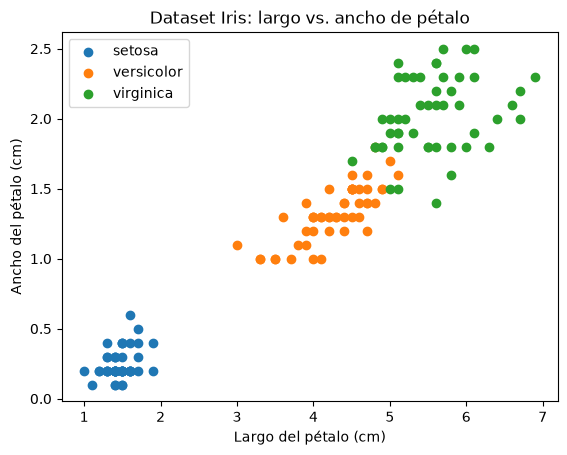

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
for especie, grupo in df.groupby("especie"):
    ax.scatter(grupo["petal length (cm)"], grupo["petal width (cm)"], label=especie)
ax.set_xlabel("Largo del pétalo (cm)")
ax.set_ylabel("Ancho del pétalo (cm)")
ax.set_title("Dataset Iris: largo vs. ancho de pétalo")
ax.legend()
plt.show()

Las tres especies (colores) se agrupan en zonas bastante distintas del gráfico. Esa estructura es justamente lo que un modelo de clasificación va a aprender a explotar.

## 3. Un vistazo al aprendizaje no supervisado

¿Qué pasa si escondemos las etiquetas de especie y le pedimos a un algoritmo que agrupe las flores sin decirle a qué especie pertenece cada una?

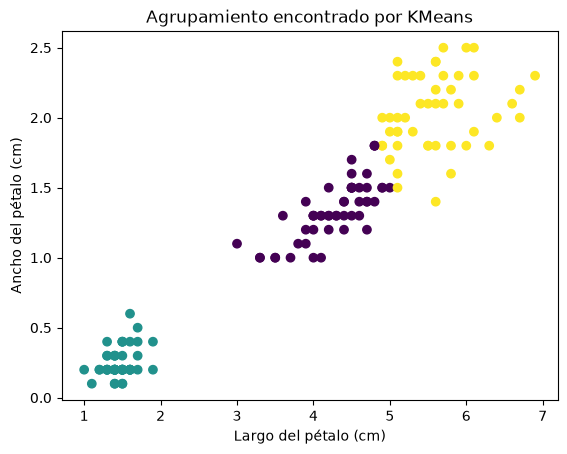

In [25]:
from sklearn.cluster import KMeans

X_iris = df[["petal length (cm)", "petal width (cm)"]]

kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
clusters = kmeans.fit_predict(X_iris)

fig, ax = plt.subplots()
scatter = ax.scatter(X_iris["petal length (cm)"], X_iris["petal width (cm)"], c=clusters, cmap="viridis")
ax.set_xlabel("Largo del pétalo (cm)")
ax.set_ylabel("Ancho del pétalo (cm)")
ax.set_title("Agrupamiento encontrado por KMeans")
plt.show()

Comparemos este gráfico con el anterior (donde coloreamos por especie real). El algoritmo encontró una separación muy parecida! El aprendizaje no supervisado encuentra patrones sin etiquetas.

## Ejercicios

**Ejercicio 1.** En la celda de la regla `es_spam_regla`, cambiá el umbral de 3 a otro valor y probá con distintos mails. ¿En qué casos falla tu intuición?

**Ejercicio 2.** Agregá 4 ejemplos nuevos al array `X`/`y` de la sección 1 (inventalos) y volvé a entrenar el modelo. ¿Cambia la predicción para `nuevo_mail = [[2, 2]]`?

**Ejercicio 3.** Usando el dataset `df` de Iris, hacé un gráfico de dispersión (`scatter`) pero con las columnas `sepal length (cm)` y `sepal width (cm)` en vez de las de pétalo. ¿Se separan igual de bien las especies? ¿Por qué te parece que pasa esto?

**Ejercicio 4 (para pensar).** Pensá un ejemplo de un problema del mundo real que se resolvería con aprendizaje supervisado, uno con no supervisado, y uno con aprendizaje por refuerzo. Justificá por qué cada uno corresponde a esa categoría.

In [8]:
# Ejercicio 1: tu código acá


In [9]:
# Ejercicio 2: tu código acá


In [10]:
# Ejercicio 3: tu código acá
